<a href="https://colab.research.google.com/github/keunsooyoon/Algorithms/blob/main/On_Structural_Criticality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

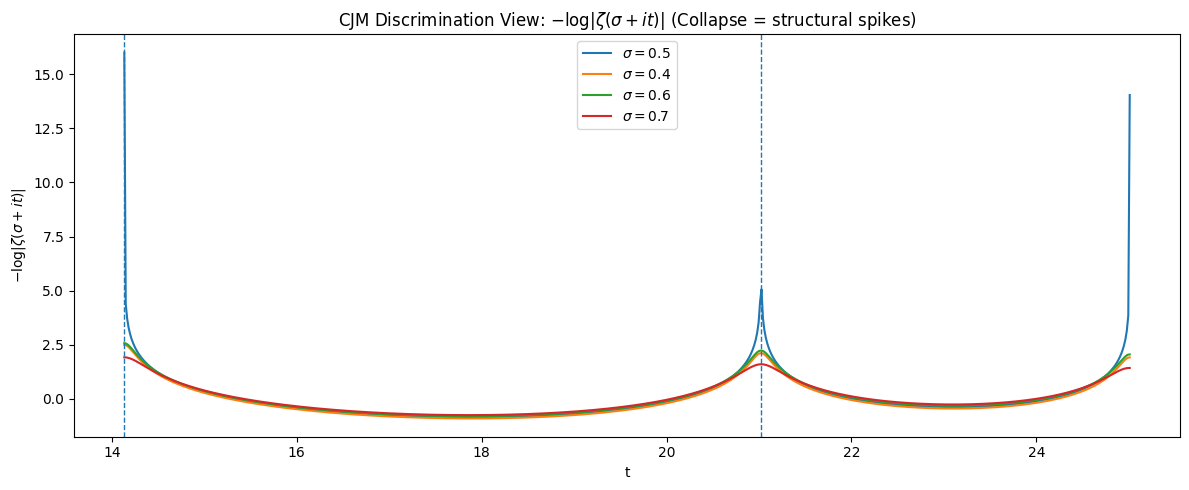

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import zeta, mp

# -----------------------------
# 0) Numerical precision
# -----------------------------
# High precision is required to resolve sharp collapse near nontrivial zeros
mp.dps = 50  # Increase to 80–100 if higher fidelity is needed

# -----------------------------
# 1) CJM-style sampling of the zeta function
# -----------------------------
def sample_zeta_neglog(sigmas, t_values, eps=1e-50):
    """
    Sample -log(|zeta(sigma + i t)|) for multiple sigma values.

    Parameters:
        sigmas   : list of real parts (sigma values)
        t_values : array of imaginary parts (t values)
        eps      : small cutoff to avoid log(0)

    Returns:
        results[sigma] = numpy array of -log(|zeta(sigma+it)|)
    """
    results = {}

    for sigma in sigmas:
        values = []
        for t in t_values:
            s = mp.mpc(sigma, t)
            z = zeta(s)

            # Magnitude of zeta
            magnitude = abs(z)

            # Safeguard against numerical underflow near zeros
            magnitude_safe = max(magnitude, mp.mpf(eps))

            # Structural collapse metric (energy-like)
            values.append(float(-mp.log(magnitude_safe)))

        results[sigma] = np.array(values, dtype=float)

    return results

# -----------------------------
# 2) Experiment window
#    (Neighborhood of the first two nontrivial zeros)
# -----------------------------
t_start = 14.134725  # First nontrivial zero
t_end   = 25.010857  # Just beyond the second nontrivial zero
N = 700              # Resolution (higher = smoother, slower)

t_vals = np.linspace(t_start, t_end, N)

# Critical line + off-critical sigma shifts
sigmas = [0.5, 0.4, 0.6, 0.7]

data = sample_zeta_neglog(sigmas, t_vals)

# -----------------------------
# 3) Single CJM discrimination plot
# -----------------------------
plt.figure(figsize=(12, 5))

for sigma in sigmas:
    plt.plot(t_vals, data[sigma], label=fr'$\sigma={sigma}$')

# Known locations of the first two nontrivial zeros
plt.axvline(14.134725, linestyle='--', linewidth=1)
plt.axvline(21.022040, linestyle='--', linewidth=1)

plt.title(r"CJM Discrimination View: $-\log|\zeta(\sigma+it)|$ (Collapse = structural spikes)")
plt.xlabel("t")
plt.ylabel(r"$-\log|\zeta(\sigma+it)|$")
plt.legend()
plt.tight_layout()
plt.show()


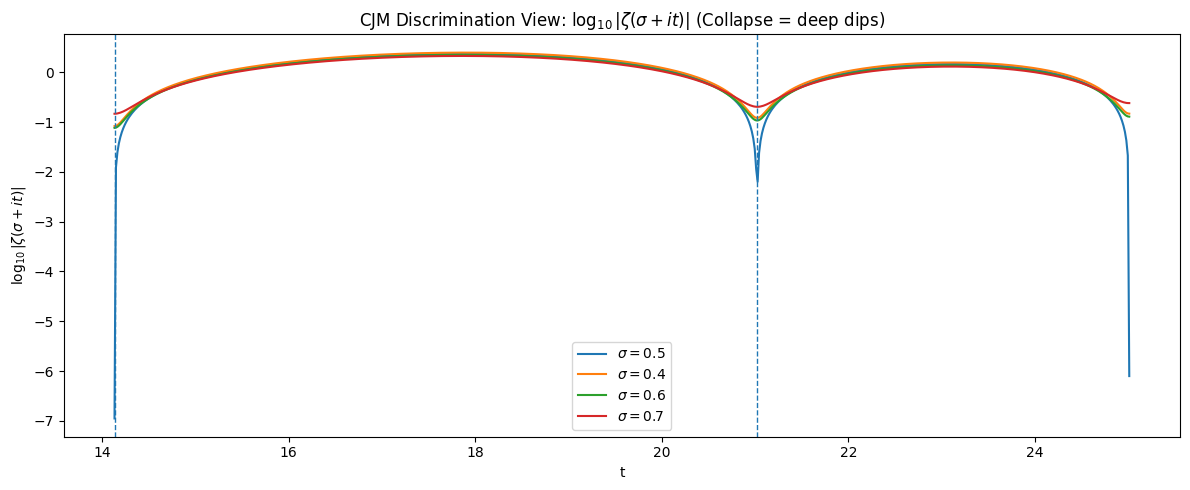

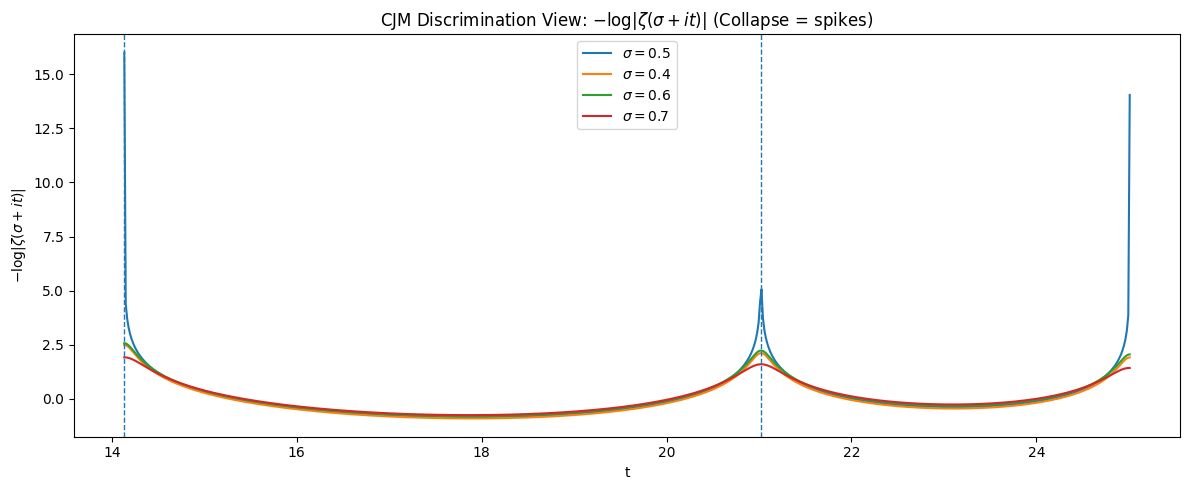

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import zeta, mp

# -----------------------------
# 0) Precision
# -----------------------------
mp.dps = 50  # 필요하면 80~100까지 올려도 됨

# -----------------------------
# 1) CJM-style sampling of zeta
# -----------------------------
def sample_zeta_abs_log_metrics(sigmas, t_values, eps=1e-50):
    """
    Returns:
      metrics[sigma] = {
        'abs': |zeta(sigma+it)|,
        'log10abs': log10(|zeta|),
        'neglogabs': -log(|zeta|)
      }
    """
    metrics = {}
    for sigma in sigmas:
        abs_list = []
        log10_list = []
        neglog_list = []

        for t in t_values:
            s = mp.mpc(sigma, t)
            z = zeta(s)
            a = abs(z)

            # guard for near-zero to avoid -inf / +inf blowing up plots
            a_safe = max(a, mp.mpf(eps))

            abs_list.append(float(a))
            log10_list.append(float(mp.log10(a_safe)))
            neglog_list.append(float(-mp.log(a_safe)))

        metrics[sigma] = {
            "abs": np.array(abs_list, dtype=float),
            "log10abs": np.array(log10_list, dtype=float),
            "neglogabs": np.array(neglog_list, dtype=float),
        }
    return metrics

# -----------------------------
# 2) Experiment window (first two nontrivial zeros neighborhood)
# -----------------------------
t_start = 14.134725
t_end   = 25.010857
N = 700  # 해상도 (늘리면 더 매끈하지만 느려짐)
t_vals = np.linspace(t_start, t_end, N)

sigmas = [0.5, 0.4, 0.6, 0.7]  # critical + multi sigma-shifts
M = sample_zeta_abs_log_metrics(sigmas, t_vals)

# -----------------------------
# 3) Plot A: log10(|zeta|)  (collapse -> deep negative dips at zeros)
# -----------------------------
plt.figure(figsize=(12, 5))
for sigma in sigmas:
    plt.plot(t_vals, M[sigma]["log10abs"], label=fr'$\sigma={sigma}$')
plt.axvline(14.134725, linestyle="--", linewidth=1)  # 1st zero (known)
plt.axvline(21.022040, linestyle="--", linewidth=1)  # 2nd zero (known)
plt.title(r"CJM Discrimination View: $\log_{10}|\zeta(\sigma+it)|$ (Collapse = deep dips)")
plt.xlabel("t")
plt.ylabel(r"$\log_{10}|\zeta(\sigma+it)|$")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Plot B: -log(|zeta|)  (collapse -> tall positive spikes at zeros)
# -----------------------------
plt.figure(figsize=(12, 5))
for sigma in sigmas:
    plt.plot(t_vals, M[sigma]["neglogabs"], label=fr'$\sigma={sigma}$')
plt.axvline(14.134725, linestyle="--", linewidth=1)
plt.axvline(21.022040, linestyle="--", linewidth=1)
plt.title(r"CJM Discrimination View: $-\log|\zeta(\sigma+it)|$ (Collapse = spikes)")
plt.xlabel("t")
plt.ylabel(r"$-\log|\zeta(\sigma+it)|$")
plt.legend()
plt.tight_layout()
plt.show()


<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-3443433968.py:21: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(t_vals, data, 'o-', label=f'$\sigma={sigma}$', linewidth=2.5, markersize=3)
/tmp/ipython-input-3443433968.py:28: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Imaginary part t'); plt.ylabel('$-\log|\zeta(\sigma+it)|$ (Structural Collapse)')


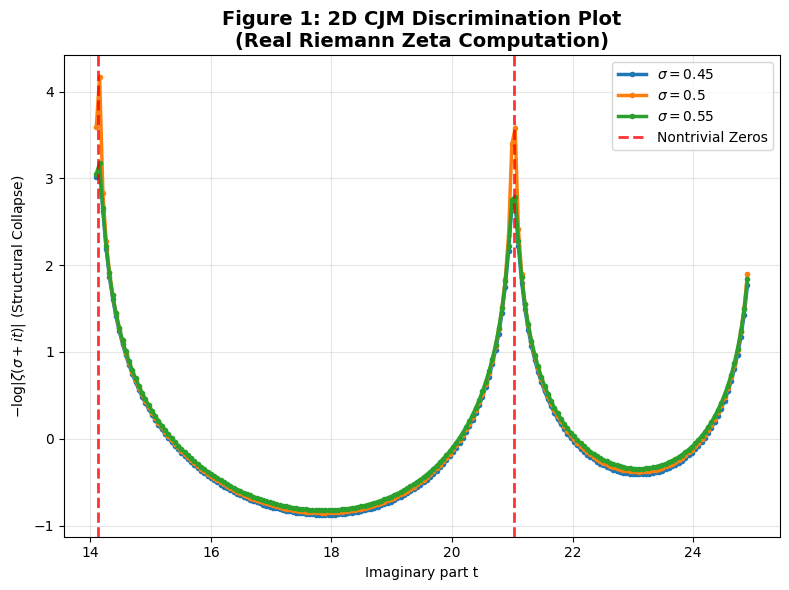

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import zeta, mp
mp.dps = 25  # High precision for nontrivial zero neighborhood computation

# Experimental window: vicinity of first two nontrivial zeros (t ∈ [14.1, 24.9])
t_vals = np.linspace(14.1, 24.9, 200)

# Critical line and off-critical σ values for CJM discrimination
sigmas = [0.45, 0.5, 0.55]  # σ=1/2 (critical line), ± deviations

# Real Riemann zeta function ζ(σ+it) computation and structural collapse metric
plt.figure(figsize=(8, 6))
for sigma in sigmas:
    # Complex points s = σ + it
    s_vals = [mp.mpc(sigma, t) for t in t_vals]
    # Zeta magnitude |ζ(s)|
    magnitudes = np.array([float(abs(zeta(s))) for s in s_vals])
    # Safeguard against log divergence near zeros
    data = -np.log(np.maximum(magnitudes, 1e-40))  # Structural collapse metric: -log|ζ|
    plt.plot(t_vals, data, 'o-', label=f'$\sigma={sigma}$', linewidth=2.5, markersize=3)

# Known nontrivial zero locations (validation reference)
plt.axvline(14.134725, ls='--', color='red', linewidth=2, alpha=0.8, label='Nontrivial Zeros')
plt.axvline(21.022040, ls='--', color='red', linewidth=2, alpha=0.8)

plt.title('Figure 1: 2D CJM Discrimination Plot\n(Real Riemann Zeta Computation)', fontsize=14, fontweight='bold')
plt.xlabel('Imaginary part t'); plt.ylabel('$-\log|\zeta(\sigma+it)|$ (Structural Collapse)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-1482236419.py:39: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Imaginary part t'); ax.set_ylabel('Real part σ'); ax.set_zlabel('$-\log|\zeta|$')


Computing zeta surface... (critical line phase stability verification)
Computing σ=0.450...
σ=0.450 complete → phase stability profile extracted
Computing σ=0.464...
σ=0.464 complete → phase stability profile extracted
Computing σ=0.479...
σ=0.479 complete → phase stability profile extracted
Computing σ=0.493...
σ=0.493 complete → phase stability profile extracted
Computing σ=0.507...
σ=0.507 complete → phase stability profile extracted
Computing σ=0.521...
σ=0.521 complete → phase stability profile extracted
Computing σ=0.536...
σ=0.536 complete → phase stability profile extracted
Computing σ=0.550...
σ=0.550 complete → phase stability profile extracted


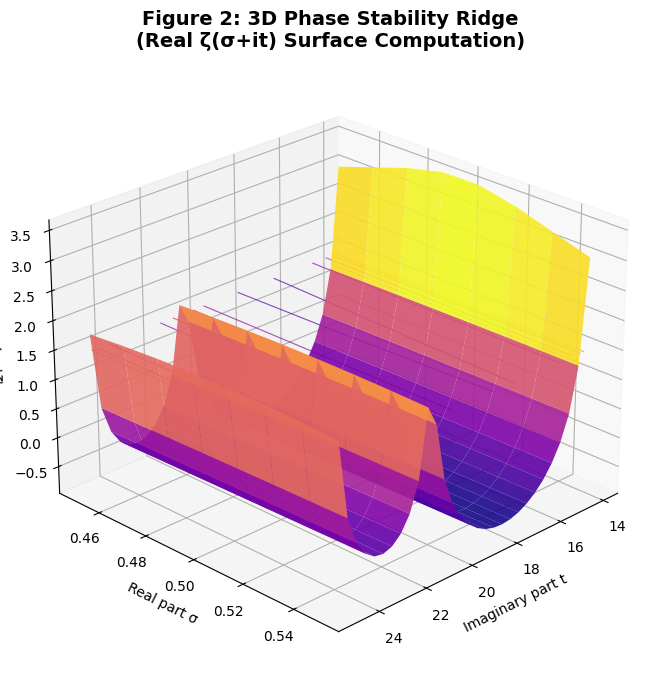

Complete: Figures 1+2 (CJM structural discrimination experiment finished)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpmath import zeta, mp
mp.dps = 25  # High precision required for ζ computation

# Minimal sampling grid for 3D surface (computational efficiency)
t_short = np.linspace(14.1, 24.9, 30)      # t-axis: 30 points
sigma_short = np.linspace(0.45, 0.55, 8)   # σ-axis: ±0.05 around critical line (8 points)

# Real zeta-based 3D structural collapse surface (240 total ζ evaluations)
print("Computing zeta surface... (critical line phase stability verification)")
Z_real = np.zeros((len(sigma_short), len(t_short)))  # Collapse metric storage matrix
for i, sig in enumerate(sigma_short):
    print(f"Computing σ={sig:.3f}...")
    for j, t in enumerate(t_short):
        # Zeta evaluation at complex point
        s = mp.mpc(sig, t)
        mag = float(abs(zeta(s)))  # |ζ(σ+it)|
        Z_real[i,j] = -np.log(max(mag, 1e-40))  # CJM structural collapse metric
    print(f"σ={sig:.3f} complete → phase stability profile extracted")

# Meshgrid for surface plotting
T, S = np.meshgrid(t_short, sigma_short)

# 3D phase stability ridge visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Structural collapse surface (real ζ data)
surf = ax.plot_surface(T, S, Z_real, cmap='plasma', alpha=0.9,
                      rstride=1, cstride=1, linewidth=0, antialiased=True)

# Contours: critical line (σ=1/2) ridge emphasis
ax.contour(T, S, Z_real, levels=6, cmap='plasma', alpha=0.7, linewidths=0.8, offset=1.5)

ax.set_title('Figure 2: 3D Phase Stability Ridge\n(Real ζ(σ+it) Surface Computation)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Imaginary part t'); ax.set_ylabel('Real part σ'); ax.set_zlabel('$-\log|\zeta|$')
ax.view_init(elev=25, azim=45)  # Optimal ridge viewing angle
plt.tight_layout()
plt.show()

